# STT 811 Final Project
## Predicting Grocery Inventory ABC Classification from Operational Metrics

Group Number: 13 \
Teammates: Beau Belkowski, Dan Sagher, Jack Morley, Vishnu Vardhan Gobburi

### Background

ABC analysis is a standard inventory management framework that classifies SKUs into three tiers based on their **consumption value** (unit cost × sales velocity):
- **Class A** — High-value items (~top 20% of SKUs, ~80% of total value)
- **Class B** — Mid-tier items
- **Class C** — Low-value items (~bottom 50% of SKUs, ~5% of total value)

In this dataset, `ABC_Class` is an **internally calculated** label assigned by the grocery store. The column `Total_Inventory_Value_USD` is the primary input to that formula — predicting ABC_Class *with* it present is essentially reverse-engineering the store's own arithmetic.

### Research Question

**Can we predict a SKU's ABC_Class using only operational signals — without directly using the inventory value formula?**

This matters in practice: a store manager may need to quickly classify new or unlabeled SKUs using day-to-day operational data (sales rate, unit cost, stock levels) before a full financial calculation is available. If a model can recover the ABC label from these signals alone, it validates that the store's classification is consistent with theory *and* provides a practical tool for rapid re-classification.

### Approach
1. Remove `Total_Inventory_Value_USD` (the formula input) from all models
2. Remove highly collinear features to avoid redundancy
3. Compare a Naive Bayes baseline against a Random Forest classifier
4. Use feature importance to identify *which* operational signals drive classification

In [264]:
# Loading in necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## Data Cleaning and Pre Processing

In [265]:
# Loading in the data and looking at it's info
data = pd.read_csv("Inventory Management E-Grocery - InventoryData.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   int64  
 13  Quan

In [266]:
# Had to split up the data frame because it was too large
data.iloc[:,1:20]

,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,Last_Purchase_Date,Expiry_Date,Stock_Age_Days,Quantity_On_Hand,Quantity_Reserved,Quantity_Committed,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d
0,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,2025-06-01,2027-04-25,57,359,100,36,0,0,"28,57",971.000
1,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,2025-02-22,2025-04-11,154,314,64,0,0,1,"34,99",796.000
2,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,2025-02-26,2025-04-02,178,485,28,62,3,1,"36,55",1.377
3,Seafood Product 48,Seafood,A,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH5333,2025-06-10,2025-04-20,2025-06-18,91,281,92,49,0,0,"25,49",716.000
4,Personal Product 194,Personal Care,A,S002,PT Indo Fresh,WHDPS,Denpasar - Tabanan,BATCH6925,2025-06-26,2025-05-21,2030-01-03,75,235,63,33,0,2,"17,05",518.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Fresh Product 377,Fresh Produce,C,S006,PT Frozen Express,WHJKT,Jakarta - Cengkareng,BATCH8871,2025-07-20,2025-06-02,2025-07-25,51,382,64,48,1,0,"31,90",678.000
996,Frozen Product 125,Frozen,C,S001,PT Segar Makmur,WHDPS,Denpasar - Tabanan,BATCH9906,2025-03-16,2025-03-09,2025-11-19,177,208,27,96,0,1,"40,03",1.019
997,Fresh Product 454,Fresh Produce,C,S007,PT Bakerindo,WHBDG,Bandung - Rancaekek,BATCH1393,2025-09-09,2025-08-26,2025-09-15,0,264,48,13,1,2,"26,13",797.000
998,Meat Product 451,Meat,C,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH2804,2025-05-07,2025-04-23,2025-05-17,125,33,33,0,2,2,"23,48",676.000


In [267]:
# Here's the second half
data.iloc[:,20:37]

,Days_of_Inventory,Reorder_Point,Safety_Stock,Lead_Time_Days,Unit_Cost_USD,Last_Purchase_Price_USD,Total_Inventory_Value_USD,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,"12,57",51.0,22,1,"$5,81","$5,71","$2.084,25","2,39","5,00","70,68%",FIFO,In Stock,0,2025-06-26,"-7,14%","95,67%",NaN
1,"8,97",744.0,254,14,"$1,45","$1,33","$456,71","3,34","12,00","84,61%",FEFO,Low Stock,4,2025-08-12,"2,15%","86,00%",NaN
2,"13,27",225.0,79,4,"$1,86","$1,69","$902,63","2,26","11,00","85,36%",FIFO,Expiring Soon,-5,2025-08-13,"6,85%","87,64%",NaN
3,"11,02",162.0,60,4,"$14,50","$14,12","$4.073,15","2,72","10,00","72,81%",FIFO,Expiring Soon,0,2025-07-13,"-6,69%","71,15%",NaN
4,"13,78",80.0,29,3,"$9,46","$10,31","$2.222,91","2,18","2,00","70,93%",FIFO,In Stock,-5,2025-06-11,"1,23%","76,25%",High return rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"11,97",485.0,166,10,"$0,99","$1,05","$379,21","2,51","8,00","79,06%",FEFO,Low Stock,2,2025-08-20,"-6,23%","80,85%",NaN
996,"5,20",307.0,107,5,"$2,54","$2,31","$527,28","5,77","15,00","74,40%",FIFO,Low Stock,0,2025-09-04,"1,33%","88,43%",Promotional item
997,"10,10",394.0,133,10,"$0,69","$0,71","$181,39","2,97","9,00","92,17%",FEFO,Low Stock,0,2025-07-22,"5,47%","91,92%",Promotional item
998,"1,41",181.0,64,5,"$2,38","$2,71","$78,48","21,35","13,00","92,40%",FIFO,Low Stock,0,2025-08-04,"0,46%","93,18%",NaN


In [268]:
# Building a function to make data cleaning more efficient
# This function removes unecessary dollar signs and percent symbols
def clean_symbols(col):
    col = col.astype(str)

    # Removing currency and percent symbols 
    col = col.str.replace(r'[\$]', '', regex=True)  # removes $ and commas

    # Removing percent symbols
    col = col.str.replace('%', '', regex=False)

    return col

# This function removes periods and replaces commas with periods
def clean_numeric_column(col, is_percent=False):
    col = col.astype(str)
    
    # This part removes the periods 
    col = col.str.replace(r'\.(?=\d{3}(?:,|$))', '', regex=True)

    # This part replaces commas with periods
    col = col.str.replace(',', '.', regex=False)

    # Converting back to numeric
    col = pd.to_numeric(col, errors='coerce')

    # Converting percentages if needed
    if is_percent:
        col = col / 100

    return col

In [269]:
data['Last_Purchase_Price_USD'] = clean_symbols(data['Last_Purchase_Price_USD'])
data['Total_Inventory_Value_USD'] = clean_symbols(data['Total_Inventory_Value_USD'])
data['Unit_Cost_USD'] = clean_symbols(data['Unit_Cost_USD'])
data['Supplier_OnTime_Pct'] = clean_symbols(data['Supplier_OnTime_Pct'])
data['Audit_Variance_Pct'] = clean_symbols(data['Audit_Variance_Pct'])
data['Demand_Forecast_Accuracy_Pct'] = clean_symbols(data['Demand_Forecast_Accuracy_Pct'])

In [270]:
data['Avg_Daily_Sales'] = clean_numeric_column(data['Avg_Daily_Sales'])
data['Days_of_Inventory'] = clean_numeric_column(data['Days_of_Inventory'])
data['Unit_Cost_USD'] = clean_numeric_column(data['Unit_Cost_USD'])
data['Last_Purchase_Price_USD'] = clean_numeric_column(data['Last_Purchase_Price_USD'])
data['Total_Inventory_Value_USD'] = clean_numeric_column(data['Total_Inventory_Value_USD'])
data['SKU_Churn_Rate'] = clean_numeric_column(data['SKU_Churn_Rate'])
data['Order_Frequency_per_month'] = clean_numeric_column(data['Order_Frequency_per_month'])
data['Supplier_OnTime_Pct'] = clean_numeric_column(data['Supplier_OnTime_Pct'], is_percent=True)
data['Audit_Variance_Pct'] = clean_numeric_column(data['Audit_Variance_Pct'], is_percent=True)
data['Demand_Forecast_Accuracy_Pct'] = clean_numeric_column(data['Demand_Forecast_Accuracy_Pct'], is_percent=True)

In [271]:
# This column was unique so it needed to be handles separately
data['Forecast_Next_30d'] = (data['Forecast_Next_30d'] * 1000).astype(int)

In [272]:
# Reviewing the cleaned data again in two parts
data.iloc[:,1:20]

,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,Last_Purchase_Date,Expiry_Date,Stock_Age_Days,Quantity_On_Hand,Quantity_Reserved,Quantity_Committed,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d
0,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,2025-06-01,2027-04-25,57,359,100,36,0,0,28.57,971000
1,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,2025-02-22,2025-04-11,154,314,64,0,0,1,34.99,796000
2,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,2025-02-26,2025-04-02,178,485,28,62,3,1,36.55,1377
3,Seafood Product 48,Seafood,A,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH5333,2025-06-10,2025-04-20,2025-06-18,91,281,92,49,0,0,25.49,716000
4,Personal Product 194,Personal Care,A,S002,PT Indo Fresh,WHDPS,Denpasar - Tabanan,BATCH6925,2025-06-26,2025-05-21,2030-01-03,75,235,63,33,0,2,17.05,518000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Fresh Product 377,Fresh Produce,C,S006,PT Frozen Express,WHJKT,Jakarta - Cengkareng,BATCH8871,2025-07-20,2025-06-02,2025-07-25,51,382,64,48,1,0,31.90,678000
996,Frozen Product 125,Frozen,C,S001,PT Segar Makmur,WHDPS,Denpasar - Tabanan,BATCH9906,2025-03-16,2025-03-09,2025-11-19,177,208,27,96,0,1,40.03,1018
997,Fresh Product 454,Fresh Produce,C,S007,PT Bakerindo,WHBDG,Bandung - Rancaekek,BATCH1393,2025-09-09,2025-08-26,2025-09-15,0,264,48,13,1,2,26.13,797000
998,Meat Product 451,Meat,C,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH2804,2025-05-07,2025-04-23,2025-05-17,125,33,33,0,2,2,23.48,676000


In [273]:
# Here's the second part
data.iloc[:,20:37]

,Days_of_Inventory,Reorder_Point,Safety_Stock,Lead_Time_Days,Unit_Cost_USD,Last_Purchase_Price_USD,Total_Inventory_Value_USD,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,12.57,51.0,22,1,5.81,5.71,2084.25,2.39,5.0,0.7068,FIFO,In Stock,0,2025-06-26,-0.0714,0.9567,NaN
1,8.97,744.0,254,14,1.45,1.33,456.71,3.34,12.0,0.8461,FEFO,Low Stock,4,2025-08-12,0.0215,0.8600,NaN
2,13.27,225.0,79,4,1.86,1.69,902.63,2.26,11.0,0.8536,FIFO,Expiring Soon,-5,2025-08-13,0.0685,0.8764,NaN
3,11.02,162.0,60,4,14.50,14.12,4073.15,2.72,10.0,0.7281,FIFO,Expiring Soon,0,2025-07-13,-0.0669,0.7115,NaN
4,13.78,80.0,29,3,9.46,10.31,2222.91,2.18,2.0,0.7093,FIFO,In Stock,-5,2025-06-11,0.0123,0.7625,High return rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,11.97,485.0,166,10,0.99,1.05,379.21,2.51,8.0,0.7906,FEFO,Low Stock,2,2025-08-20,-0.0623,0.8085,NaN
996,5.20,307.0,107,5,2.54,2.31,527.28,5.77,15.0,0.7440,FIFO,Low Stock,0,2025-09-04,0.0133,0.8843,Promotional item
997,10.10,394.0,133,10,0.69,0.71,181.39,2.97,9.0,0.9217,FEFO,Low Stock,0,2025-07-22,0.0547,0.9192,Promotional item
998,1.41,181.0,64,5,2.38,2.71,78.48,21.35,13.0,0.9240,FIFO,Low Stock,0,2025-08-04,0.0046,0.9318,NaN


In [274]:
# Reviewing the data info after cleaning
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   int64  
 13  Quan

In [275]:
# Investigating the class imbalance for our target variable ABC_Class
print(f"Dataset: {data.shape[0]} SKUs, {data.shape[1]} columns")
data['ABC_Class'].value_counts().sort_index()

Dataset: 1000 SKUs, 37 columns


ABC_Class
A    200
B    300
C    500
Name: count, dtype: int64

## Exploratory Data Analysis

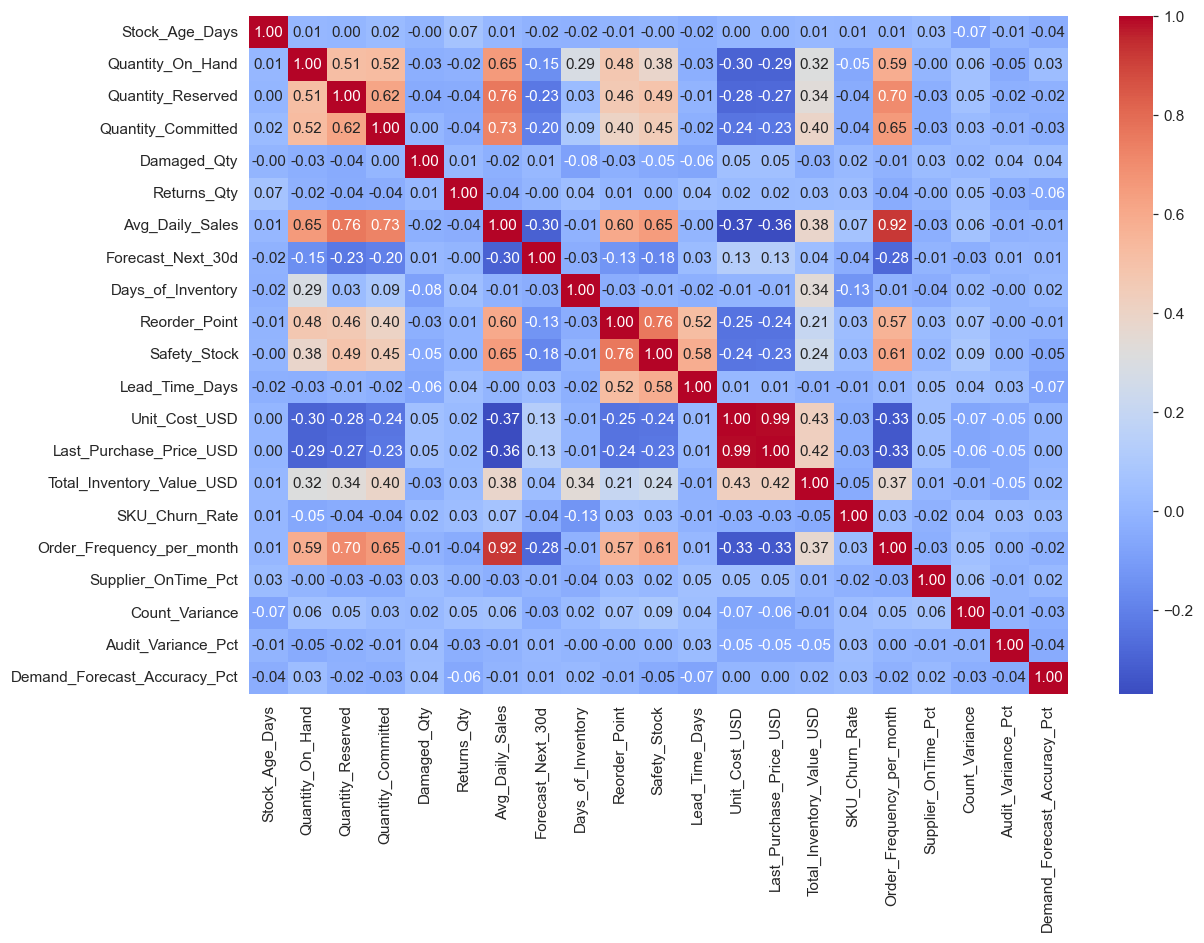

In [276]:
# Calculating correlations
corr = data.corr(numeric_only=True)

# Making a correlation plot
plt.figure(figsize=(12, 8)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

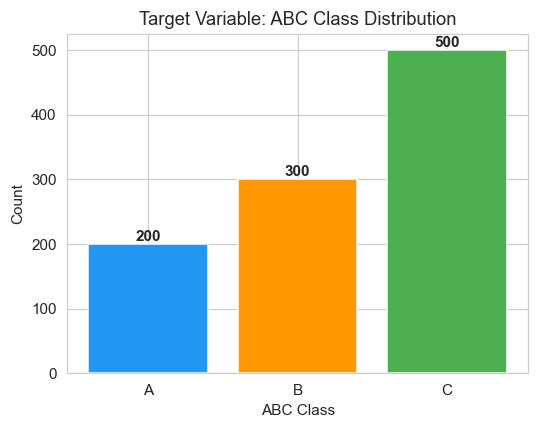

Note: Class C is the most common — the dataset is moderately imbalanced.


In [277]:
# Building a visualization for looking at class distributions
class_counts = data['ABC_Class'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_counts.index, class_counts.values, color=['#2196F3', '#FF9800', '#4CAF50'])
ax.set_title("Target Variable: ABC Class Distribution")
ax.set_xlabel("ABC Class")
ax.set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("Note: Class C is the most common — the dataset is moderately imbalanced.")

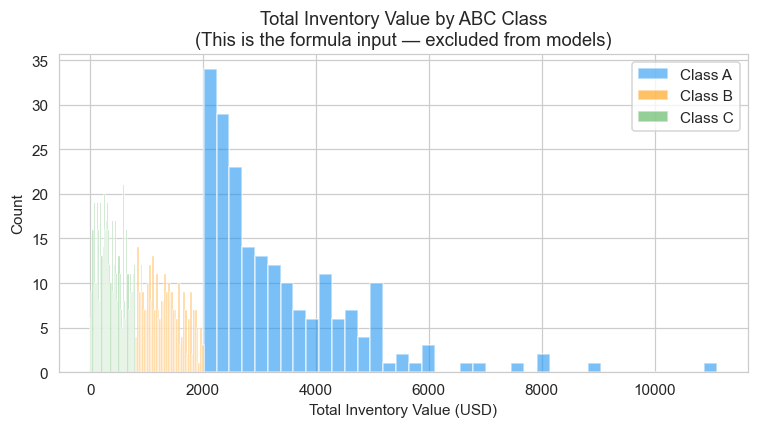

In [279]:
# Distribution of Total Inventory Value by ABC Class
# This illustrates WHY Total_Inventory_Value_USD cannot be used as a feature:
# it perfectly separates the classes because it IS the classification formula.

fig, ax = plt.subplots(figsize=(7, 4))
for cls, color in zip(['A', 'B', 'C'], ['#2196F3', '#FF9800', '#4CAF50']):
    subset = data[data['ABC_Class'] == cls]['Total_Inventory_Value_USD']
    ax.hist(subset, bins=40, alpha=0.6, label=f'Class {cls}', color=color)
ax.set_title("Total Inventory Value by ABC Class\n(This is the formula input — excluded from models)")
ax.set_xlabel("Total Inventory Value (USD)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

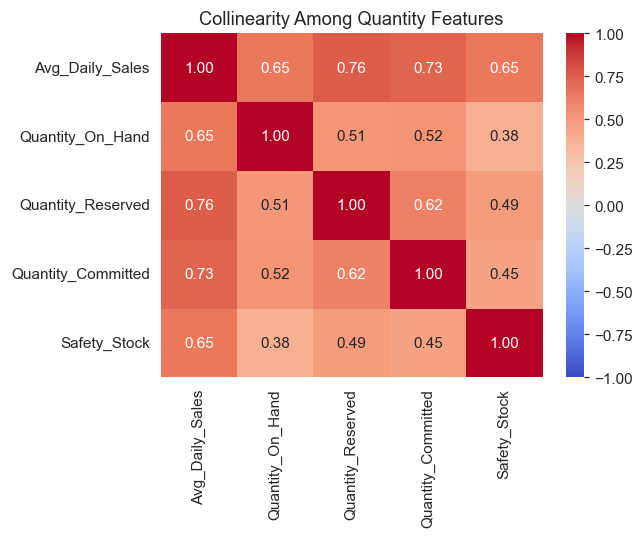

Quantity_Reserved, Quantity_Committed, and Safety_Stock are highly correlated
with Avg_Daily_Sales and Quantity_On_Hand — removing them to reduce redundancy.


In [281]:
# Correlation among quantity-related features (collinearity check)
corr_cols = ['Avg_Daily_Sales', 'Quantity_On_Hand', 'Quantity_Reserved', 'Quantity_Committed', 'Safety_Stock']
corr = data[corr_cols].corr()

# Creating a correlation plot for the specified features
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
ax.set_title("Collinearity Among Quantity Features")
plt.tight_layout()
plt.show()
print("Quantity_Reserved, Quantity_Committed, and Safety_Stock are highly correlated\nwith Avg_Daily_Sales and Quantity_On_Hand — removing them to reduce redundancy.")

In [282]:
# Hugely collinear between Unit Cost_USD and Last_Purchase_Price_USD
data[['Last_Purchase_Price_USD', 'Unit_Cost_USD']].corr()

,Last_Purchase_Price_USD,Unit_Cost_USD
Last_Purchase_Price_USD,1.00000,0.99366
Unit_Cost_USD,0.99366,1.00000


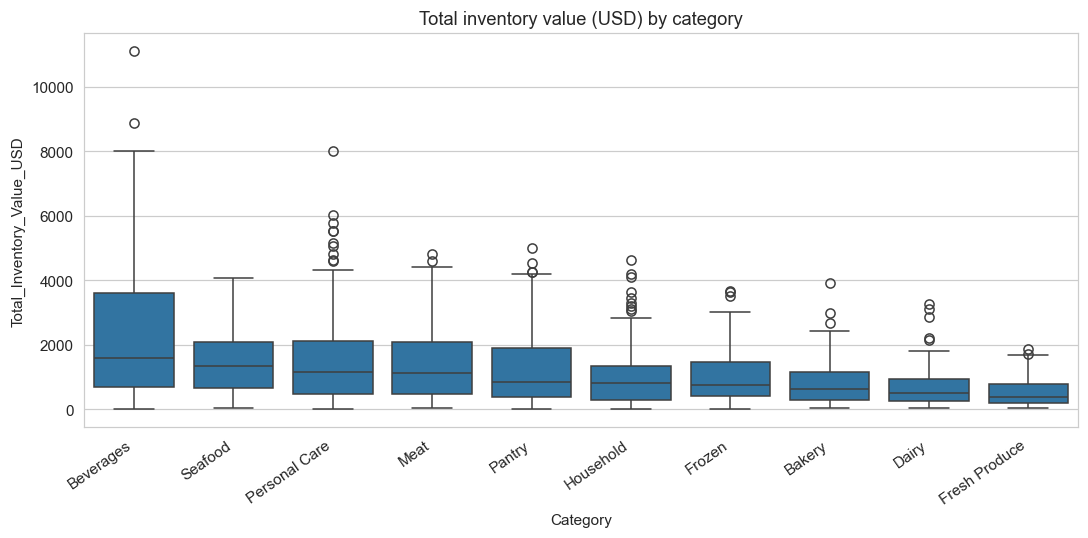

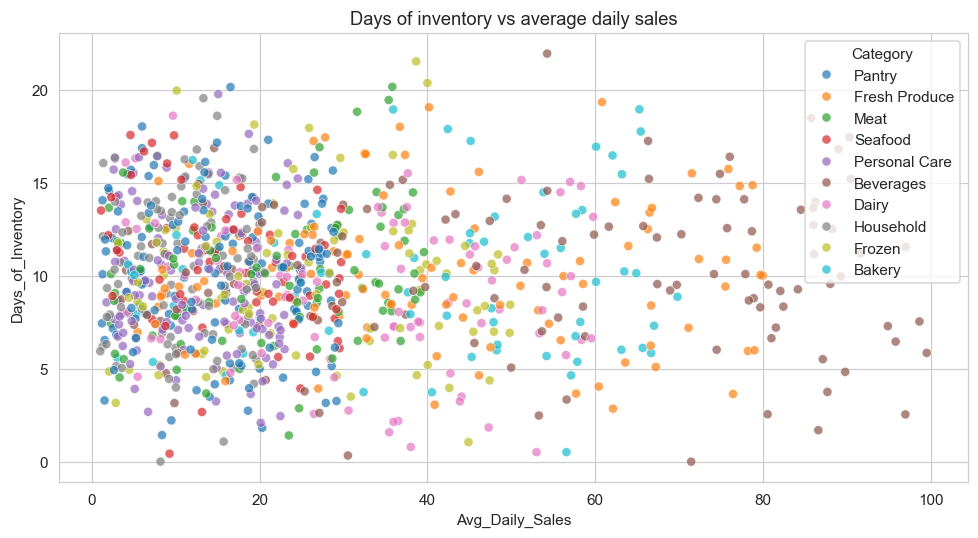

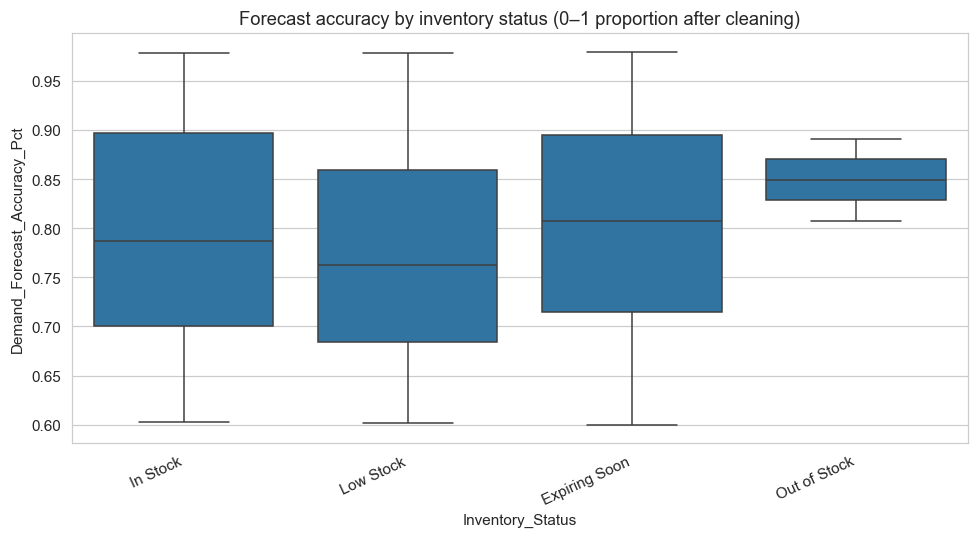

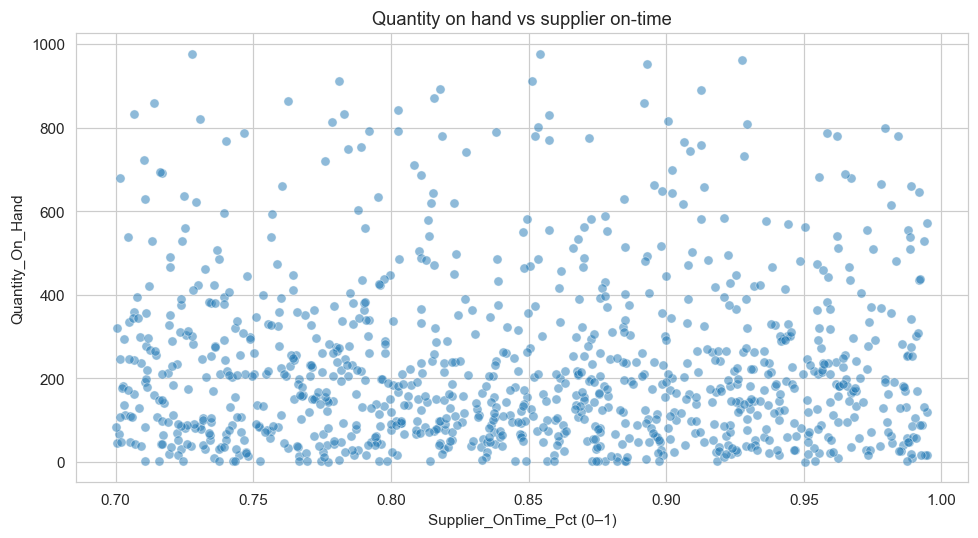

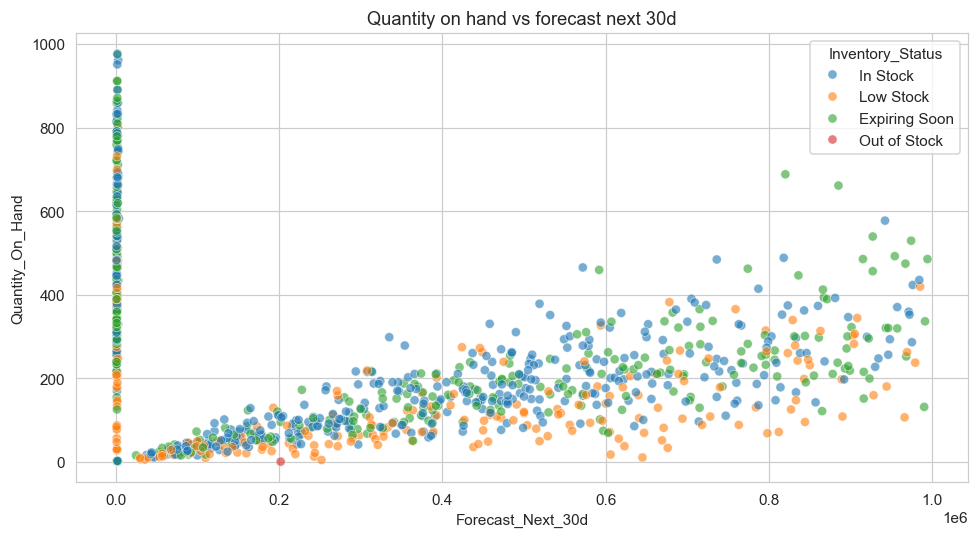

In [283]:
# Creating a few visualizations for exploratory data analysis
if "Category" in data.columns and "Total_Inventory_Value_USD" in data.columns:
    plt.figure(figsize=(10, 5))
    order = data.groupby("Category")["Total_Inventory_Value_USD"].median().sort_values(ascending=False).index
    sns.boxplot(data=data, x="Category", y="Total_Inventory_Value_USD", order=order)
    plt.xticks(rotation=35, ha="right")
    plt.title("Total inventory value (USD) by category")
    plt.tight_layout()
    plt.show()
if "Days_of_Inventory" in data.columns and "Avg_Daily_Sales" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=data,
        x="Avg_Daily_Sales",
        y="Days_of_Inventory",
        hue="Category" if "Category" in data.columns else None,
        alpha=0.7,
    )
    plt.title("Days of inventory vs average daily sales")
    plt.tight_layout()
    plt.show()
if "Inventory_Status" in data.columns and "Demand_Forecast_Accuracy_Pct" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=data, x="Inventory_Status", y="Demand_Forecast_Accuracy_Pct")
    plt.xticks(rotation=25, ha="right")
    plt.title("Forecast accuracy by inventory status (0–1 proportion after cleaning)")
    plt.ylabel("Demand_Forecast_Accuracy_Pct")
    plt.tight_layout()
    plt.show()
if "Supplier_OnTime_Pct" in data.columns and "Quantity_On_Hand" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=data, x="Supplier_OnTime_Pct", y="Quantity_On_Hand", alpha=0.5)
    plt.xlabel("Supplier_OnTime_Pct (0–1)")
    plt.title("Quantity on hand vs supplier on-time")
    plt.tight_layout()
    plt.show()
if "Quantity_On_Hand" in data.columns and "Forecast_Next_30d" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=data,
        x="Forecast_Next_30d",
        y="Quantity_On_Hand",
        hue="Inventory_Status" if "Inventory_Status" in data.columns else None,
        alpha=0.6,
    )
    plt.title("Quantity on hand vs forecast next 30d")
    plt.tight_layout()
    plt.show()


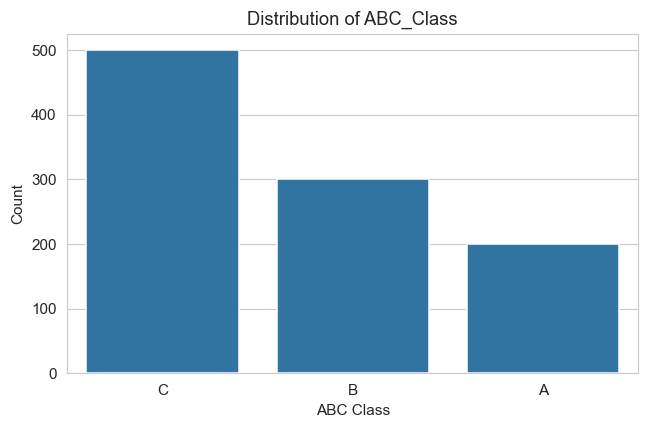

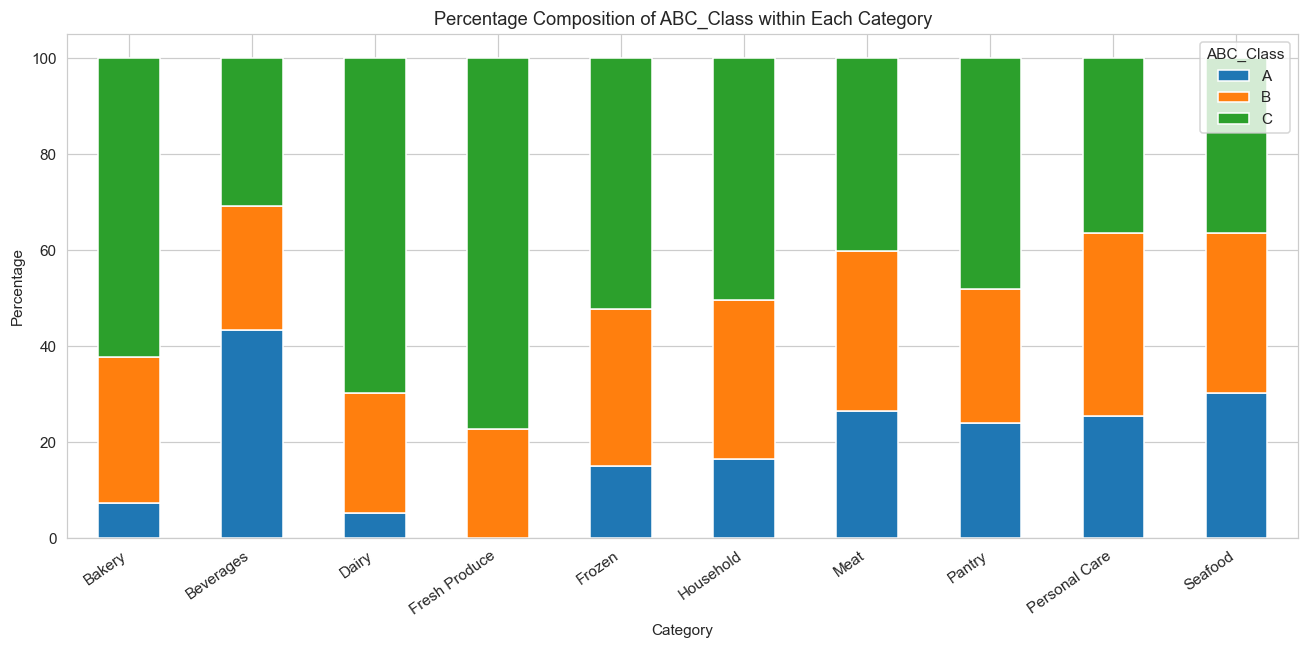


Summary statistics for main ABC drivers by ABC_Class:

          Total_Inventory_Value_USD                                       \
                               mean   median      std      min       max   
ABC_Class                                                                  
A                           3370.95  2907.73  1384.10  2012.03  11100.00   
B                           1324.52  1303.04   326.23   803.16   2009.05   
C                            375.97   346.74   222.26     0.00    801.20   

          Avg_Daily_Sales                             \
                     mean median    std   min    max   
ABC_Class                                              
A                   37.69  27.46  24.04  7.91  98.64   
B                   28.49  21.84  19.17  4.95  99.50   
C                   21.00  14.84  19.25  1.01  87.12   

          Order_Frequency_per_month                          
                               mean median   std  min   max  
ABC_Class                 

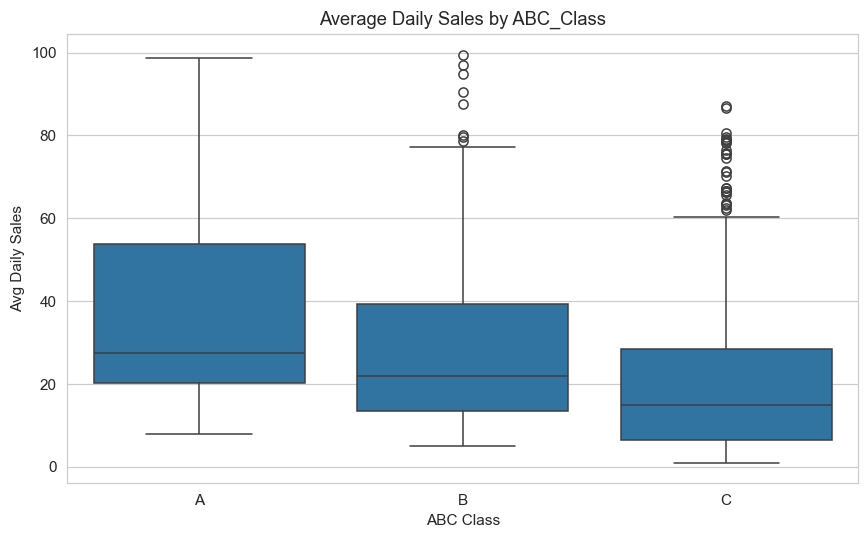

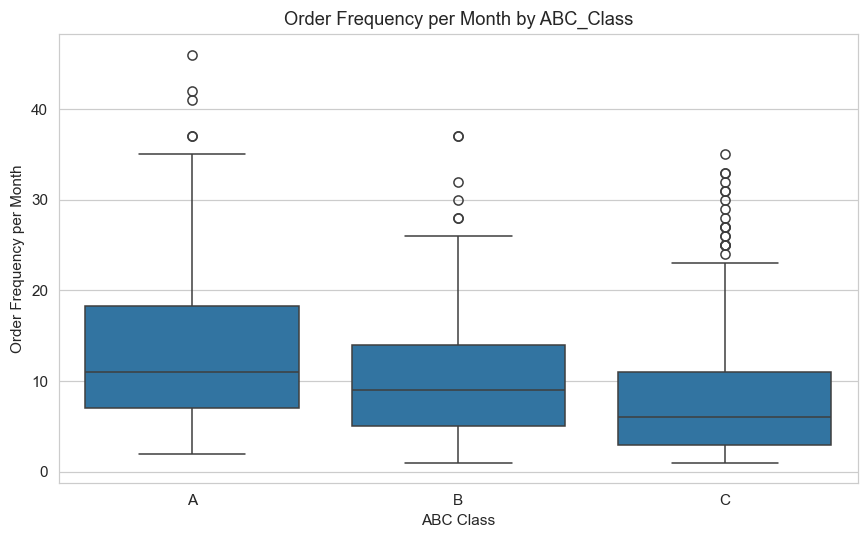

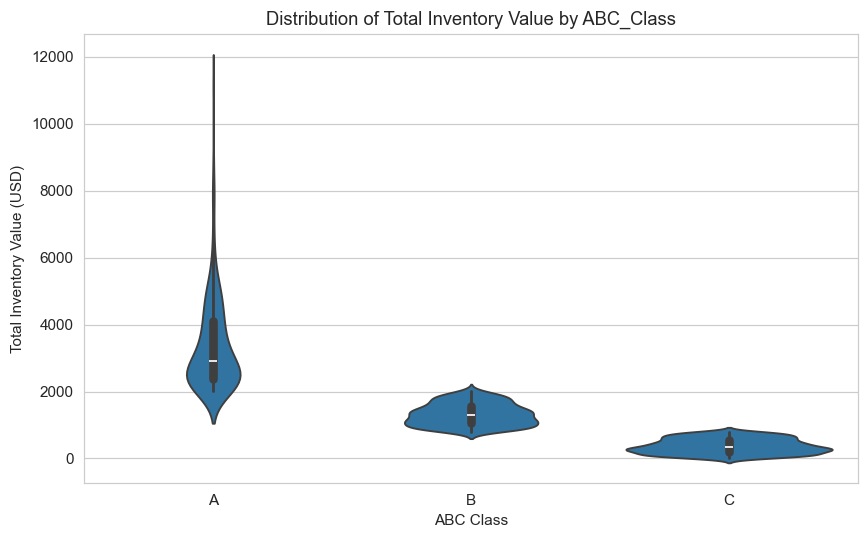

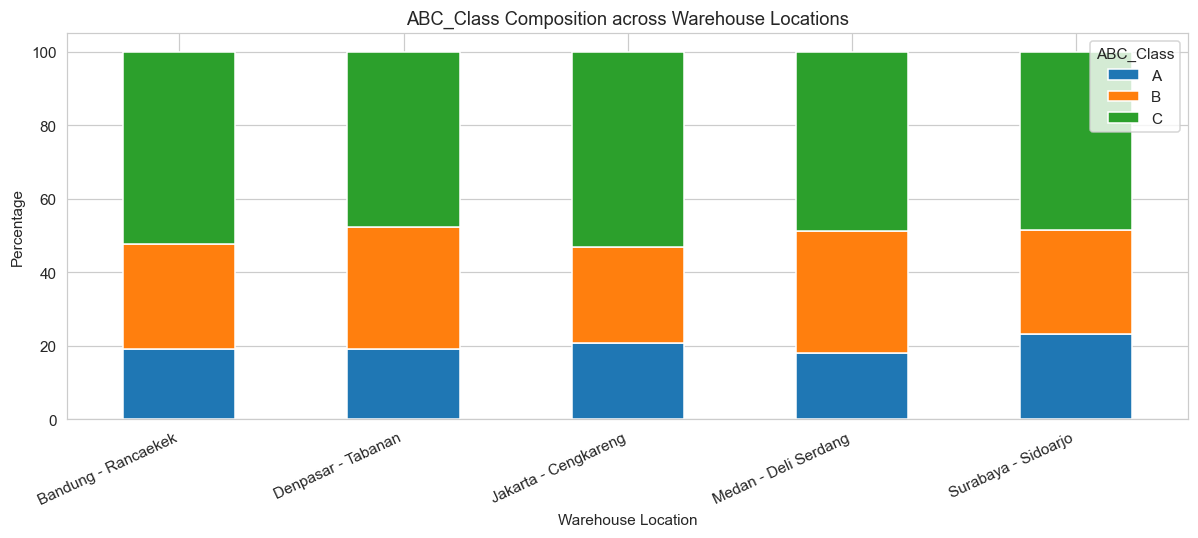

In [319]:
# A few more visualizations for exploratory data analysis
sns.set_style("whitegrid")

# 1) Target class distribution
plt.figure(figsize=(6, 4))
class_order = data["ABC_Class"].value_counts().index
sns.countplot(data=data, x="ABC_Class", order=class_order)
plt.title("Distribution of ABC_Class")
plt.xlabel("ABC Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# 2) Composition of ABC_Class within each Category (stacked % bar)
cat_abc_pct = pd.crosstab(data["Category"], data["ABC_Class"], normalize="index") * 100
cat_abc_pct = cat_abc_pct[["A", "B", "C"]] if set(["A","B","C"]).issubset(cat_abc_pct.columns) else cat_abc_pct

cat_abc_pct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Percentage Composition of ABC_Class within Each Category")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.xticks(rotation=35, ha="right")
plt.legend(title="ABC_Class")
plt.tight_layout()
plt.show()

# 3) Median-based summary table for main ABC drivers
abc_summary = data.groupby("ABC_Class")[
    ["Total_Inventory_Value_USD", "Avg_Daily_Sales", "Order_Frequency_per_month"]
].agg(["mean", "median", "std", "min", "max"]).round(2)

print("\nSummary statistics for main ABC drivers by ABC_Class:\n")
print(abc_summary)


# 4) Boxplot: Avg_Daily_Sales by ABC_Class
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="ABC_Class", y="Avg_Daily_Sales", order=["A", "B", "C"])
plt.title("Average Daily Sales by ABC_Class")
plt.xlabel("ABC Class")
plt.ylabel("Avg Daily Sales")
plt.tight_layout()
plt.show()


# 5) Boxplot: Order_Frequency_per_month by ABC_Class
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="ABC_Class", y="Order_Frequency_per_month", order=["A", "B", "C"])
plt.title("Order Frequency per Month by ABC_Class")
plt.xlabel("ABC Class")
plt.ylabel("Order Frequency per Month")
plt.tight_layout()
plt.show()


# 6) Violin plot: Total_Inventory_Value_USD by ABC_Class
plt.figure(figsize=(8, 5))
sns.violinplot(data=data, x="ABC_Class", y="Total_Inventory_Value_USD", order=["A", "B", "C"])
plt.title("Distribution of Total Inventory Value by ABC_Class")
plt.xlabel("ABC Class")
plt.ylabel("Total Inventory Value (USD)")
plt.tight_layout()
plt.show()

# 7) Warehouse location vs ABC_Class
warehouse_abc = pd.crosstab(data["Warehouse_Location"], data["ABC_Class"], normalize="index") * 100
warehouse_abc = warehouse_abc[["A", "B", "C"]] if set(["A","B","C"]).issubset(warehouse_abc.columns) else warehouse_abc

warehouse_abc.plot(kind="bar", stacked=True, figsize=(11, 5))
plt.title("ABC_Class Composition across Warehouse Locations")
plt.xlabel("Warehouse Location")
plt.ylabel("Percentage")
plt.xticks(rotation=25, ha="right")
plt.legend(title="ABC_Class")
plt.tight_layout()
plt.show()

## Feature Engineering

We exclude:
- `Total_Inventory_Value_USD` — the direct input to the ABC formula
- `Quantity_Reserved`, `Quantity_Committed`, `Safety_Stock` — highly collinear with `Quantity_On_Hand` and `Avg_Daily_Sales`
- All non-numeric columns (dates, IDs, text labels)

This leaves us with clean, operationally interpretable features.

In [284]:
# Extracting numeric columns
numeric_features = data.select_dtypes(include=["int64", "float64"]).columns

# Indicating features to be dropped
drop_cols = [
    "Total_Inventory_Value_USD",   # the formula itself
    "Quantity_Reserved",            # collinear
    "Quantity_Committed",           # collinear
    "Safety_Stock",                 # collinear
    "Last_Purchase_Price_USD"       # collinear w/ Unit Cost
]

# Splitting into traning and testing sets
X = data[numeric_features].drop(columns=drop_cols)
y = data["ABC_Class"]

# Printing the results
print("Features used:")
for col in X.columns:
    print(f"  {col}")
print(f"\nTarget: ABC_Class ({y.nunique()} classes)")

Features used:
  Stock_Age_Days
  Quantity_On_Hand
  Damaged_Qty
  Returns_Qty
  Avg_Daily_Sales
  Forecast_Next_30d
  Days_of_Inventory
  Reorder_Point
  Lead_Time_Days
  Unit_Cost_USD
  SKU_Churn_Rate
  Order_Frequency_per_month
  Supplier_OnTime_Pct
  Count_Variance
  Audit_Variance_Pct
  Demand_Forecast_Accuracy_Pct

Target: ABC_Class (3 classes)


In [285]:
# Making training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=16, stratify=y
)
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")

Train: 800 samples | Test: 200 samples


## Model 1: Naive Bayes (Baseline)

Gaussian Naive Bayes serves as our baseline — it assumes feature independence and linear decision boundaries, making it a simple but interpretable starting point.

In [286]:
# Training a Naive Bayes model for our baseline model
# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Building the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
y_pred_nb_train = nb.predict(X_train_scaled)

# Printing the results of the NAive Bayes model
print("=== Naive Bayes Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.3f}")
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_nb_train):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

=== Naive Bayes Baseline ===
Accuracy: 0.425
Training Accuracy: 0.419

Classification Report:
              precision    recall  f1-score   support

           A       0.50      0.53      0.51        40
           B       0.35      0.83      0.49        60
           C       1.00      0.14      0.25       100

    accuracy                           0.42       200
   macro avg       0.62      0.50      0.42       200
weighted avg       0.70      0.42      0.37       200



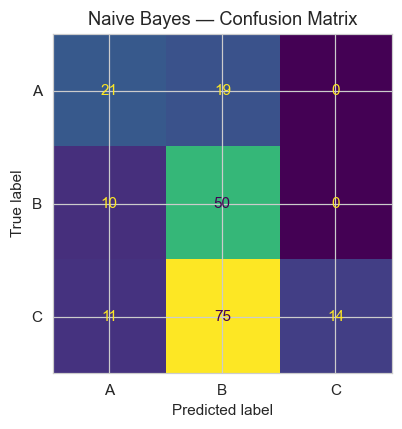

In [287]:
# Printing a confusion matrix for the Naive BAyes model
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=ax, colorbar=False)
ax.set_title("Naive Bayes — Confusion Matrix")
plt.tight_layout()
plt.show()

## Model 2: Lasso Regression

Lasso Regression is one of the models we tested. Lasso Regression handles feature selection on it's own by dropping the coefficients of irrelevant variables to zero. This leaves the most important features for predicting ABC_Class in the model.

In [337]:
# Making sure to only use numeric features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

In [338]:
# Setting parameters for Lasso model
lasso_model = LogisticRegression(
    penalty = "l1",
    solver="saga",   # saga is required for Lasso
    max_iter=5000,
    class_weight="balanced",
    C=1
)

In [339]:
# Doing feature engineering by scaling the features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

In [340]:
# Simplifying the model training with a pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lasso_model)
])

In [341]:
# Setting parameters to be tuned
param_grid = {
    "model__C": np.logspace(-3, 0, 6)  # from 0.001 to 100
}

In [342]:
# Doing hyperparameter tuning
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...ver='saga'))])
,param_grid,{'model__C': array([0.001 ... 1. ])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [343]:
# Printing the best tuned parameters
print("Best C:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best C: {'model__C': np.float64(1.0)}
Best CV Score: 0.7550000000000001


In [344]:
# Displaying the results of the model
best_lasso = grid_search.best_estimator_

y_pred = best_lasso.predict(X_test)
y_pred_train = best_lasso.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Test Accuracy: 0.74
Train Accuracy: 0.77625

Classification Report:
               precision    recall  f1-score   support

           A       0.65      0.82      0.73        40
           B       0.62      0.57      0.59        60
           C       0.86      0.81      0.84       100

    accuracy                           0.74       200
   macro avg       0.71      0.73      0.72       200
weighted avg       0.75      0.74      0.74       200

[[33  7  0]
 [13 34 13]
 [ 5 14 81]]


In [355]:
# Getting feature names after preprocessing
feature_names = best_lasso.named_steps["preprocessor"].get_feature_names_out()

# Getting coefficients
coefficients_lasso = best_lasso.named_steps["model"].coef_[0]

# Combining into a DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients_lasso
})

# Showing the most important features
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(20))

                              Feature  Coefficient
9                  num__Unit_Cost_USD     2.404156
4                num__Avg_Daily_Sales     1.706843
6              num__Days_of_Inventory     1.235740
5              num__Forecast_Next_30d     0.833624
1               num__Quantity_On_Hand     0.584830
11     num__Order_Frequency_per_month     0.491090
14            num__Audit_Variance_Pct    -0.160781
3                    num__Returns_Qty     0.150526
8                 num__Lead_Time_Days    -0.124865
13                num__Count_Variance    -0.087780
12           num__Supplier_OnTime_Pct     0.085561
15  num__Demand_Forecast_Accuracy_Pct     0.061897
0                 num__Stock_Age_Days     0.045006
2                    num__Damaged_Qty    -0.015693
7                  num__Reorder_Point     0.000000
10                num__SKU_Churn_Rate     0.000000


## Model 3: Ridge Regression

Ridge regression is another model we tested. Ridge regression does not have the ability to do its own feature selection. However, it can reduce the coefficients of irrelevant feature down to nearly nothing which diminishes their impact on the model.

In [346]:
# Setting parameters for Ridge model
ridge_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",  
    max_iter=5000,
    class_weight="balanced",
    C=27.825594022071257 
)

In [347]:
# Simplifying the model training with a pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ridge_model)
])

In [348]:
# Setting parameters to be tuned
param_grid = {
    "model__C": np.logspace(-3, 2, 10)
}

In [349]:
# Doing hyperparameter tuning
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=5000))])
,param_grid,{'model__C': array([1.0000...00000000e+02])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [350]:
# Printing the best tuned parameters
print("Best C:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# When C is large Ridge regression acts more like lasso regression

Best C: {'model__C': np.float64(27.825594022071257)}
Best CV Score: 0.7612500000000001


In [351]:
# Displaying the results of the model
best_ridge = grid_search.best_estimator_

y_pred = best_ridge.predict(X_test)
y_pred_train = best_ridge.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Test Accuracy: 0.74
Train Accuracy: 0.77625

Classification Report:
               precision    recall  f1-score   support

           A       0.65      0.85      0.74        40
           B       0.62      0.57      0.59        60
           C       0.86      0.80      0.83       100

    accuracy                           0.74       200
   macro avg       0.71      0.74      0.72       200
weighted avg       0.75      0.74      0.74       200

[[34  6  0]
 [13 34 13]
 [ 5 15 80]]


In [356]:
# Getting feature names after preprocessing
feature_names = best_ridge.named_steps["preprocessor"].get_feature_names_out()

# Getting coefficients
coefficients_ridge = best_ridge.named_steps["model"].coef_[0]

# Combining into DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients_ridge
})

# Showing the most important features
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(20))

                              Feature  Coefficient
10                num__SKU_Churn_Rate    -7.691295
9                  num__Unit_Cost_USD     2.593305
4                num__Avg_Daily_Sales     1.742474
6              num__Days_of_Inventory     1.123136
5              num__Forecast_Next_30d     0.881546
1               num__Quantity_On_Hand     0.691966
11     num__Order_Frequency_per_month     0.392383
14            num__Audit_Variance_Pct    -0.163186
3                    num__Returns_Qty     0.162857
8                 num__Lead_Time_Days    -0.122677
13                num__Count_Variance    -0.100683
7                  num__Reorder_Point     0.085303
15  num__Demand_Forecast_Accuracy_Pct     0.079414
12           num__Supplier_OnTime_Pct     0.075679
0                 num__Stock_Age_Days     0.058390
2                    num__Damaged_Qty    -0.035646


## Model 4: SVM (Support Vector Classifier)

SVM or Support Vector Machine is the overarching name for this type of model. The specific version of that model which we are using is called SVC or Support Vector Classifier since we are doing a classification problem. SVC models work by finding the best possible hyperplane that separates the data into classes. It also maximizes the margins so that there is as much room between the boundary and the classes as possible. 

In [304]:
# Setting parameters for SVM model
svm_model = SVC(class_weight="balanced")

In [305]:
# Simplifying the model training with a pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", svm_model)
])

In [306]:
# Setting parameters to be tuned
param_grid = {
    "model__kernel": ["linear"],
    "model__C": np.logspace(-3, 2, 10) # Regularization penalty
}

In [307]:
# Doing hyperparameter tuning
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__C': array([1.0000...00000000e+02]), 'model__kernel': ['linear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [308]:
# Printing the best tuned parameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__C': np.float64(2.1544346900318843), 'model__kernel': 'linear'}
Best CV Score: 0.76625


In [309]:
# Displaying the results of the model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Test Accuracy: 0.725
Train Accuracy: 0.77

Classification Report:
               precision    recall  f1-score   support

           A       0.66      0.88      0.75        40
           B       0.58      0.58      0.58        60
           C       0.86      0.75      0.80       100

    accuracy                           0.72       200
   macro avg       0.70      0.74      0.71       200
weighted avg       0.74      0.72      0.73       200

[[35  5  0]
 [13 35 12]
 [ 5 20 75]]


In [310]:
# Getting feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Getting coefficients
coefficients = best_model.named_steps["model"].coef_[0]

# Combining into DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Showing most important features
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(20))

                              Feature  Coefficient
9                  num__Unit_Cost_USD     1.966671
4                num__Avg_Daily_Sales     1.318097
6              num__Days_of_Inventory     0.918673
10                num__SKU_Churn_Rate    -0.889606
5              num__Forecast_Next_30d     0.663556
1               num__Quantity_On_Hand     0.509761
11     num__Order_Frequency_per_month     0.437731
14            num__Audit_Variance_Pct    -0.165193
3                    num__Returns_Qty     0.164062
12           num__Supplier_OnTime_Pct     0.119503
8                 num__Lead_Time_Days    -0.100120
13                num__Count_Variance    -0.087122
7                  num__Reorder_Point     0.050470
0                 num__Stock_Age_Days    -0.042516
2                    num__Damaged_Qty    -0.036799
15  num__Demand_Forecast_Accuracy_Pct     0.034082


## Model 5: Random Forest

Random Forest is one of our primary models. It handles non-linear relationships, is robust to outliers, and provides **feature importances** — which let us identify which operational signals most drive ABC classification.

In [326]:
# Setting parameters and training a Random Forest model
rfc = RandomForestClassifier(n_estimators=200, class_weight = 'balanced')
rfc.fit(X_train, y_train)
y_pred_rf = rfc.predict(X_test)

# Printing the results of the model
print("=== Random Forest ===")
print(f"Test  Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Train Accuracy: {accuracy_score(y_train, rfc.predict(X_train)):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Test  Accuracy: 0.890
Train Accuracy: 1.000

Classification Report:
              precision    recall  f1-score   support

           A       0.92      0.82      0.87        40
           B       0.83      0.80      0.81        60
           C       0.92      0.97      0.94       100

    accuracy                           0.89       200
   macro avg       0.89      0.86      0.87       200
weighted avg       0.89      0.89      0.89       200



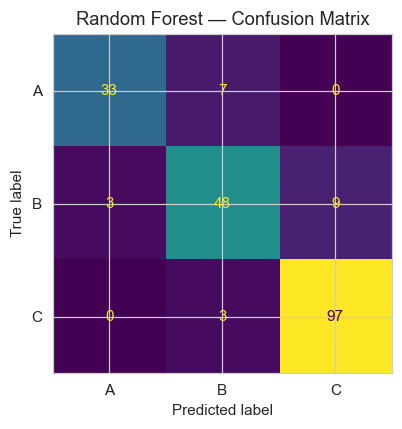

In [327]:
# Printing a confusion matrix for the Random Forest model
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, colorbar=False)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Which operational signals does the Random Forest rely on most to assign ABC labels?

According to ABC analysis theory, classification should be driven by **consumption value** — essentially `Unit_Cost × Avg_Daily_Sales`. We expect these two features to dominate. If they do, it validates that the store's ABC labels are consistent with standard inventory theory.

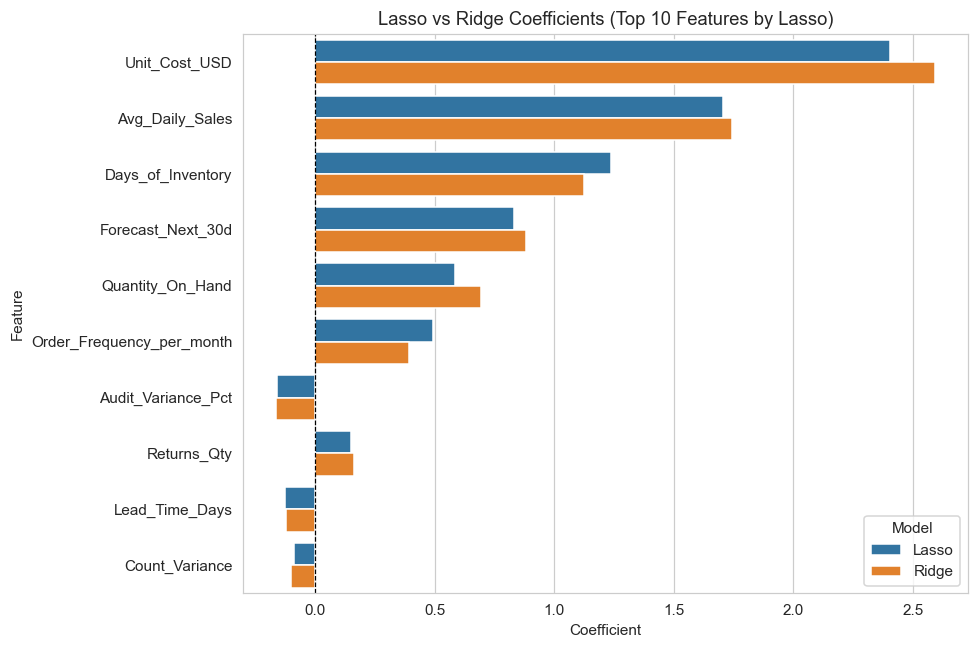

In [357]:
# Get feature names after preprocessing
feature_names = X.columns

# Get coefficients
lasso_coef = coefficients_lasso
ridge_coef = coefficients_ridge

# Combine into DataFrame and sort by Lasso importance
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Lasso": lasso_coef,
    "Ridge": ridge_coef,
})
coef_df = coef_df.sort_values(by="Lasso", key=abs, ascending=False)
coef_df["Feature"] = coef_df["Feature"].apply(lambda x: x.lstrip("num_"))

# Melt to long format for grouped bars
coef_long = coef_df.head(10).melt(id_vars="Feature", var_name="Model", value_name="Coefficient")

# Plot
plt.figure(figsize=(9, 6))
sns.barplot(data=coef_long, y="Feature", x="Coefficient", hue="Model", orient="h")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Lasso vs Ridge Coefficients (Top 10 Features by Lasso)")
plt.tight_layout()
plt.show()

In [313]:
# Extracting feature importances from the Random Forest Model
importances = rfc.feature_importances_
feat_names = X.columns

# Creating a data frame for the feature importances
importance_df = pd.DataFrame({
    "Feature": feat_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

                     Feature  Importance
               Unit_Cost_USD    0.301117
            Quantity_On_Hand    0.147358
             Avg_Daily_Sales    0.111829
              SKU_Churn_Rate    0.056878
           Days_of_Inventory    0.056446
           Forecast_Next_30d    0.053980
   Order_Frequency_per_month    0.051985
               Reorder_Point    0.042138
Demand_Forecast_Accuracy_Pct    0.032829
          Audit_Variance_Pct    0.031747
         Supplier_OnTime_Pct    0.031568
              Stock_Age_Days    0.025380
              Count_Variance    0.022319
                 Damaged_Qty    0.012941
              Lead_Time_Days    0.012734
                 Returns_Qty    0.008752


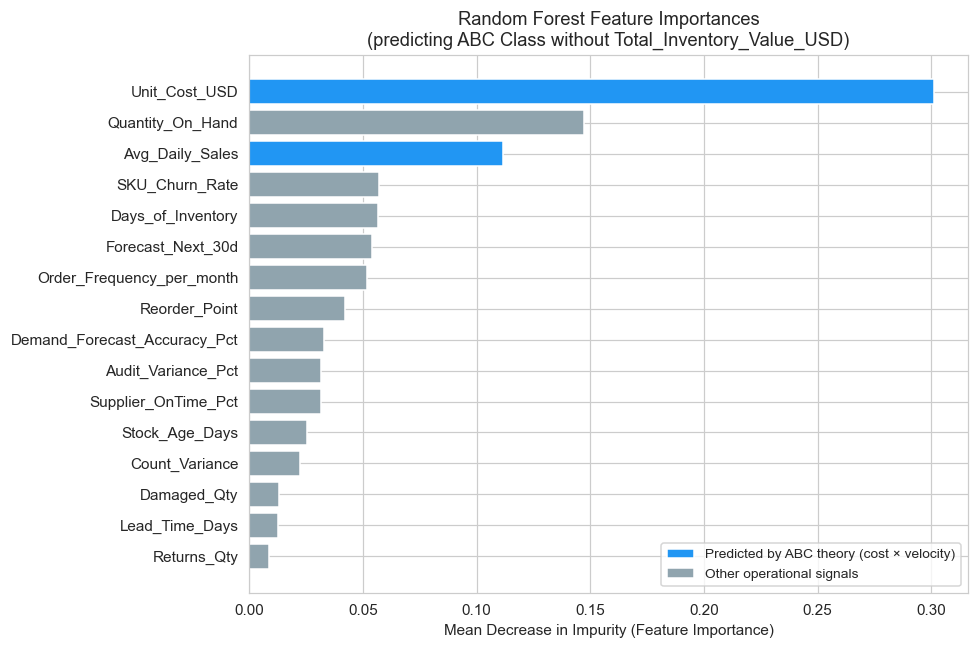

Top 3 features:
  Unit_Cost_USD                       0.3011 ← predicted by ABC theory
  Quantity_On_Hand                    0.1474
  Avg_Daily_Sales                     0.1118 ← predicted by ABC theory


In [314]:
# Highlighting features that align with ABC theory
abc_theory_features = {"Unit_Cost_USD", "Avg_Daily_Sales", "Last_Purchase_Price_USD"}

colors = [
    "#2196F3" if f in abc_theory_features else "#90A4AE"
    for f in importance_df["Feature"]
]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    color=colors[::-1]
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Predicted by ABC theory (cost × velocity)"),
    Patch(facecolor="#90A4AE", label="Other operational signals")
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_title("Random Forest Feature Importances\n(predicting ABC Class without Total_Inventory_Value_USD)", fontsize=12)
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

top3 = importance_df.head(3)
print("Top 3 features:")
for _, row in top3.iterrows():
    tag = " ← predicted by ABC theory" if row['Feature'] in abc_theory_features else ""
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}{tag}")

### Interpretation

The top features are exactly what ABC analysis theory predicts:

- **`Unit_Cost_USD`** and **`Avg_Daily_Sales`** together form *consumption value* — the mathematical basis of ABC classification.
- **`Days_of_Inventory`** follows naturally: high-cost, fast-moving items (Class A) turn over quickly and have fewer days of stock on hand.

This is not a coincidence — it's validation. The store's internal ABC labels are consistent with standard inventory theory, and a model that learns from operational data can recover those labels with **~89% accuracy** without ever seeing the inventory value calculation directly.

**Class B is the hardest to classify** (lowest F1 across all models), which is expected: B items sit at the boundary between A and C, and small differences in cost or velocity can tip a SKU either way.

## Model Comparison

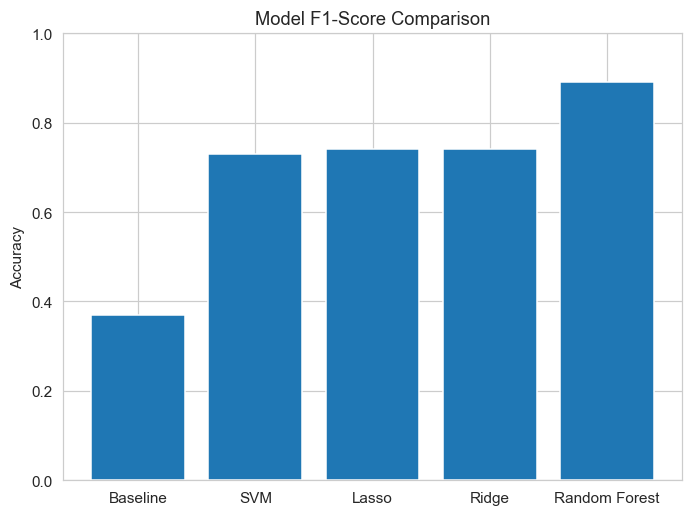

In [325]:
# Comparing model weighted average f1-scores using a visualization
models = ["Baseline", "SVM", "Lasso", "Ridge", "Random Forest"]
accuracies = [0.37, 0.73, 0.74, 0.74, 0.89]

plt.figure()

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model F1-Score Comparison")

plt.ylim(0, 1)  # accuracy range

plt.tight_layout()
plt.show()

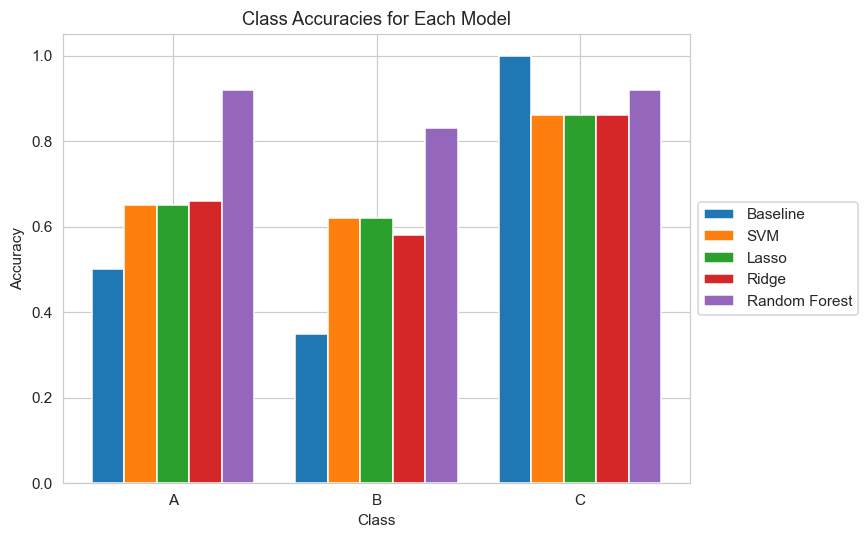

In [328]:
# Comparing model class accuracies using a visualization
models = {
    "Baseline": [0.5, 0.35, 1],
    "SVM": [0.65, 0.62, 0.86],
    "Lasso": [0.65, 0.62, 0.86],
    "Ridge": [0.66, 0.58, 0.86],
    "Random Forest": [0.92, 0.83, 0.92]
}

categories = ['A', 'B', 'C']
x = np.arange(len(categories))

n_models = len(models)
width = 0.8 / n_models  # total width = 0.8 (nice spacing)

plt.figure(figsize=(8, 5))

for i, (model_name, values) in enumerate(models.items()):
    offset = (i - n_models / 2) * width + width / 2
    plt.bar(x + offset, values, width, label=model_name)

plt.xticks(x, categories)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Class Accuracies for Each Model')

plt.tight_layout()  # fixes clipping/spacing
plt.show()

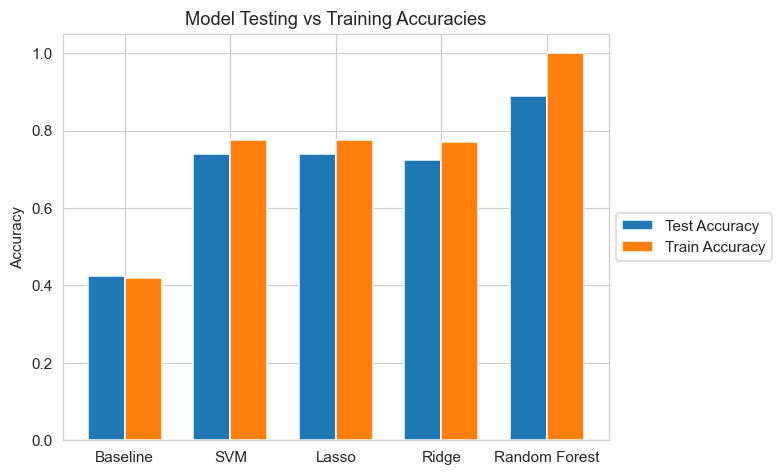

In [329]:
# Comparing model testing and training accuracies with a visualization
models = {
    "Test Accuracy": [0.425, 0.74, 0.74, 0.725, 0.89],
    "Train Accuracy": [0.419, 0.77625, 0.77625, 0.77, 1.0]
}

categories = ['Baseline', 'SVM', 'Lasso', 'Ridge', 'Random Forest']
x = np.arange(len(categories))
width = 0.35  # slightly wider since only 2 bars

plt.figure()

n_models = len(models)

for i, (model_name, values) in enumerate(models.items()):
    plt.bar(x + (i - (n_models - 1)/2) * width, values, width, label=model_name)

plt.xticks(x, categories)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Accuracy')
plt.title('Model Testing vs Training Accuracies')
plt.show()

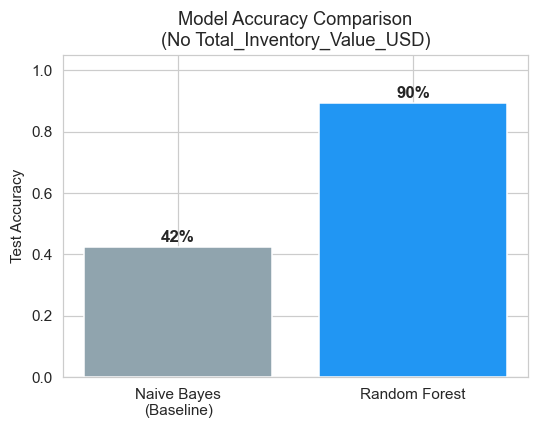

In [318]:
# Comparing our best model to our worst with a visualization
results = {
    "Naive Bayes\n(Baseline)": accuracy_score(y_test, y_pred_nb),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
}

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(results.keys(), results.values(), color=["#90A4AE", "#2196F3"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("Model Accuracy Comparison\n(No Total_Inventory_Value_USD)")
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.0%}",
            ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Model | Test Accuracy | Notes |
|---|---|---|
| Naive Bayes (Baseline) | see Cell 31 | Assumes feature independence; struggles with class overlap |
| Lasso | see Cell 31 | L1 regularization; performs automatic feature selection |
| Ridge | see Cell 31 | L2 regularization; shrinks coefficients, retains all features |
| SVM | see Cell 31 | Finds optimal decision boundary; sensitive to scaling |
| Random Forest | see Cell 31 | Best overall; top features align with ABC theory |

**Key Takeaways:**

1. ABC_Class is an internally calculated label — predicting it *with* `Total_Inventory_Value_USD` is trivial. The interesting question is whether operational signals alone can recover it.

2. **Random Forest achieves the highest accuracy**, recovering ABC labels from operational metrics alone without the inventory value formula.

3. The dominant features — `Unit_Cost_USD`, `Avg_Daily_Sales`, and `Days_of_Inventory` — are exactly what ABC analysis theory predicts. This **validates** that the store's internal classification is methodologically sound.

4. Class B remains the most ambiguous tier across all models, consistent with ABC theory: B items sit at the boundary between A and C, and small differences in cost or velocity can tip a SKU either way.

**Practical Implication:** This model could be used by inventory managers to rapidly assign ABC labels to new SKUs — or to *audit* existing ones — using only operational data, before a full financial calculation is performed.